# Chapter 1: GPU Architecture & the Roofline Model

Your A100 has 312 TFLOPS of FP16 compute. During LLM decode, it uses less than 1% of that.
The GPU isn't slow, it's **starved**. Every token requires loading billions of weight bytes from memory, and the math finishes before the next bytes arrive. This chapter measures the two hardware limits that explain everything in this series.

**By end of this notebook:**
- Measured peak memory bandwidth and TFLOPS on your A100
- Built a roofline plot from *measured* data (not spec-sheet numbers)
- Placed LLM linear-layer ops at different batch sizes on that roofline
- Calculated LLaMA-3.2-1B model size in FP32/FP16/INT8/INT4

**Approach:** Fill in every `# YOUR CODE` section yourself - that's the learning.
Expected outputs are shown after each benchmark cell.

---

**GPU architecture coverage:**

This chapter focuses on the **high-level hardware limits** that determine performance:
- Memory bandwidth (HBM ↔ compute units)
- Compute throughput (FLOPS)
- The roofline model (when each bottleneck matters)

**What's not covered here:** Lower-level architecture details like SM internals, shared memory/SRAM management, warps, thread blocks, and registers. These come in **Chapter 5: Writing GPU Kernels with Triton**, where you'll need them to explicitly control memory movement and write kernels that stay on-chip instead of round-tripping to HBM.

**Why this order?** You need to understand *what* limits performance (this chapter) before learning *how* to work around those limits (Chapter 5).

---

**A100 80GB SXM theoretical numbers (verify these):**
| Metric | Theoretical |
|--------|-------------|
| Memory bandwidth | ~2,000 GB/s |
| FP16 TFLOPS | 312 (no sparsity) |
| Ridge point (FP16) | 156 FLOPS/byte |

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt

assert torch.cuda.is_available(), "No CUDA device — check Remote SSH connection"

device = torch.device('cuda')
props  = torch.cuda.get_device_properties(device)
print(f"GPU      : {props.name}")
print(f"VRAM     : {props.total_memory / 1e9:.1f} GB")
print(f"SM count : {props.multi_processor_count}")
print(f"PyTorch  : {torch.__version__}")
print(f"CUDA     : {torch.version.cuda}")

# Expected:
# GPU      : NVIDIA A100 80GB PCIe  (or SXM variant)
# VRAM     : 80.0 GB
# SM count : 108

GPU      : NVIDIA A100-SXM4-80GB
VRAM     : 85.1 GB
SM count : 108
PyTorch  : 2.5.1+cu124
CUDA     : 12.4


**What these numbers mean:**

- **GPU**: Model name — A100 comes in PCIe (400W, cheaper) and SXM (500W, faster interconnect). You have SXM.
- **VRAM**: Total HBM2e (High Bandwidth Memory) capacity. This is where model weights and activations live during inference. 80GB vs 40GB variants exist.
- **SM count**: Streaming Multiprocessors — the compute units that execute kernels. Each SM has CUDA cores, tensor cores, shared memory. A100 has 108 (or 104 if 4 are disabled for yields). More SMs = more parallel work.
- **PyTorch**: Your installed version. 2.5.1 with CUDA 12.4 backend (vs theoretical 2.10 + CUDA 12.6 in CONTEXT.md).
- **CUDA**: Runtime version PyTorch was compiled against. Determines which GPU features/optimizations are available.

**Why this matters for benchmarking:**  
SM count affects compute ceiling. VRAM size limits max batch size. CUDA version can change kernel performance by 10–20% between releases.

## Section 1: Memory Bandwidth

The limiting factor for memory-bound operations (LLM decode at batch=1, most of LLM inference).

**Method:** Allocate two large FP16 tensors. Copy `x → y`. Time it.
- Copy reads `N` bytes from HBM **and** writes `N` bytes → `2N` bytes transferred total
- Bandwidth (GB/s) = bytes_transferred / time_seconds / 1e9

**Use `torch.cuda.Event` for timing, not `time.time()`.**  
`time.time()` includes Python overhead and CPU↔GPU sync gaps. Events are recorded on the GPU timeline.

```python
start = torch.cuda.Event(enable_timing=True)
end   = torch.cuda.Event(enable_timing=True)
start.record()
# ... GPU work ...
end.record()
torch.cuda.synchronize()        # wait for GPU to finish
elapsed_ms = start.elapsed_time(end)   # milliseconds
```

In [3]:
def measure_bandwidth_GBs(size_gb=4.0, dtype=torch.float16, n_trials=20):
    """
    Measure peak HBM memory bandwidth by timing a large tensor copy.
    Returns bandwidth in GB/s.

    size_gb   : size of each tensor in GB
    n_trials  : number of copies to average over
    """
    bytes_per_element = torch.tensor([], dtype=dtype).element_size()
    n_elements = int(size_gb * 1e9 / bytes_per_element)

    x = torch.ones(n_elements, dtype=dtype, device='cuda')
    y = torch.empty_like(x)

    # Warm-up: 3 unmetered copies to let the GPU reach steady-state clock
    for _ in range(3):
        y.copy_(x)
    torch.cuda.synchronize()

    start = torch.cuda.Event(enable_timing=True)
    end   = torch.cuda.Event(enable_timing=True)

    start.record()
    for _ in range(n_trials):
        y.copy_(x)
    end.record()
    torch.cuda.synchronize()

    elapsed_ms = start.elapsed_time(end)

    # --- YOUR CODE ---
    bytes_per_trial  = 2 * bytes_per_element *  n_elements  # What HBM operations does a single tensor copy perform?
    total_bytes      = bytes_per_trial * n_trials
    time_s           = elapsed_ms / 1000
    bw_GBs           = total_bytes / time_s / 1e9  # Bandwidth = total data moved / time, in GB/s

    return bw_GBs


bw = measure_bandwidth_GBs()
print(f"Measured bandwidth : {bw:.0f} GB/s")
print(f"Theoretical peak   : 2000 GB/s")
print(f"Efficiency         : {bw / 2000 * 100:.1f}%")

# Expect: 1600-1900 GB/s (80-95% efficiency for a large memcpy on A100)

Measured bandwidth : 1772 GB/s
Theoretical peak   : 2000 GB/s
Efficiency         : 88.6%


**So what does this number mean for LLMs?**

At batch=1 decode, LLaMA-3.2-1B loads its entire 2.5 GB weight matrix (FP16) from HBM for *every single token*. At 1,774 GB/s, that's ~1.4 ms just to move the bytes — and the GPU spends almost all of that time waiting for data, not doing math.

This is the fundamental bottleneck: **bandwidth, not compute, limits how fast you generate tokens.** The next section measures the compute ceiling to see just how underutilised it is.

## Section 2: Compute Throughput (TFLOPS)

The compute ceiling. For LLM inference at batch=1, we almost never reach this.

**Method:** Large FP16 matmul. Count the FLOPs analytically.

For a matmul `(M, K) @ (K, N) → (M, N)`:
- Each output element requires `K` multiply-accumulate (MAC) ops
- Each MAC = 1 multiply + 1 add = **2 FLOPs**
- Total: **2 × M × N × K FLOPs**

Use large square matrices (8192×8192) to fully saturate all 108 SMs and their tensor cores.

In [4]:
def measure_tflops(M=8192, N=8192, K=8192, dtype=torch.float16, n_trials=20):
    """
    Measure peak FP16 TFLOPS via large matrix multiply.
    Returns throughput in TFLOPS.
    """
    A = torch.randn(M, K, dtype=dtype, device='cuda')
    B = torch.randn(K, N, dtype=dtype, device='cuda')

    # Warm-up
    for _ in range(3):
        C = torch.matmul(A, B)
    torch.cuda.synchronize()

    start = torch.cuda.Event(enable_timing=True)
    end   = torch.cuda.Event(enable_timing=True)

    start.record()
    for _ in range(n_trials):
        C = torch.matmul(A, B)
    end.record()
    torch.cuda.synchronize()

    elapsed_ms = start.elapsed_time(end)

    # --- YOUR CODE ---
    flops_per_matmul = 2 * M * N * K # Output has M*N elements. Each is a dot product of length K. How many ops per MAC?
    total_flops      = flops_per_matmul * n_trials
    time_s           = elapsed_ms / 1000
    tflops           = total_flops / time_s / 1e12  # Throughput in TFLOPS

    return tflops


tfl = measure_tflops()
print(f"Measured FP16 TFLOPS : {tfl:.0f}")
print(f"Theoretical peak     : 312 TFLOPS")
print(f"Efficiency           : {tfl / 312 * 100:.1f}%")

# Expect: 250-300 TFLOPS (80-95% for a large square FP16 matmul)

Measured FP16 TFLOPS : 266
Theoretical peak     : 312 TFLOPS
Efficiency           : 85.3%


## Section 3: The Roofline Plot

**Arithmetic intensity** = how much compute an operation does per byte it loads from memory.

`arithmetic intensity = FLOPs / bytes accessed`

- **memcpy**: reads N bytes, does 0 useful math → ~0 FLOP/byte
- **vector add** (a + b): reads 2N bytes, does N adds → ~0.5 FLOP/byte
- **LLM decode** (batch=1 linear): loads the whole weight matrix, one multiply-add per weight → ~1 FLOP/byte
- **Large matmul** (8192×8192): reuses data across output elements → 100s of FLOP/byte

A low number = "mostly moving data, barely computing". A high number = "squeezing lots of math out of each byte fetched".

---

**The roofline model** uses intensity + your hardware limits to predict max achievable throughput.

**The plot has:**
- **x-axis:** arithmetic intensity (FLOPS / byte, log scale)
- **y-axis:** achieved throughput (TFLOPS, log scale)
- **The roofline curve:** the entire performance ceiling, made of two regions:
  - **Sloped line (left side):** memory-bound region where throughput = bandwidth × intensity
  - **Flat ceiling (right side):** compute-bound region where throughput = peak TFLOPS
- **Ridge point:** the x-coordinate (intensity value) where the slope meets the ceiling

On your A100: ridge point ≈ 134 FLOPS/byte (the vertical dashed line in the plot).

---

**What "left" and "right" mean:**

These refer to positions relative to the **ridge point** (the vertical line at ~134 FLOPS/byte).

**To the LEFT of the ridge point (intensity < 134 FLOPS/byte):**
- **Memory-bound** — limited by how fast bytes arrive from HBM
- Your achieved throughput = bandwidth × intensity (you're on the sloped part)
- The tensor cores are mostly idle, waiting for data
- Example: batch=1 decode at ~1 FLOP/byte — sitting 134× to the left of the ridge

**To the RIGHT of the ridge point (intensity > 134 FLOPS/byte):**
- **Compute-bound** — limited by tensor core speed
- Your achieved throughput = peak TFLOPS (you've hit the flat ceiling)
- Memory bandwidth isn't the problem anymore; the math can't keep up with the data
- Example: large training matmuls with high data reuse

**The ridge point is a phase transition** — the intensity value where you switch from being bottlenecked by memory to being bottlenecked by compute.

---

**Why LLM decode is so slow:**

At batch=1, decode has intensity ~1 FLOP/byte — far to the left of the ridge at ~134. The GPU loads billions of weight bytes from HBM but does only one multiply-add per weight. The tensor cores spend 99% of their time idle, starved for data. KV cache eliminates quadratic attention recompute, but the linear layers still dominate — loading ~2.5 GB of weights per token at batch=1.

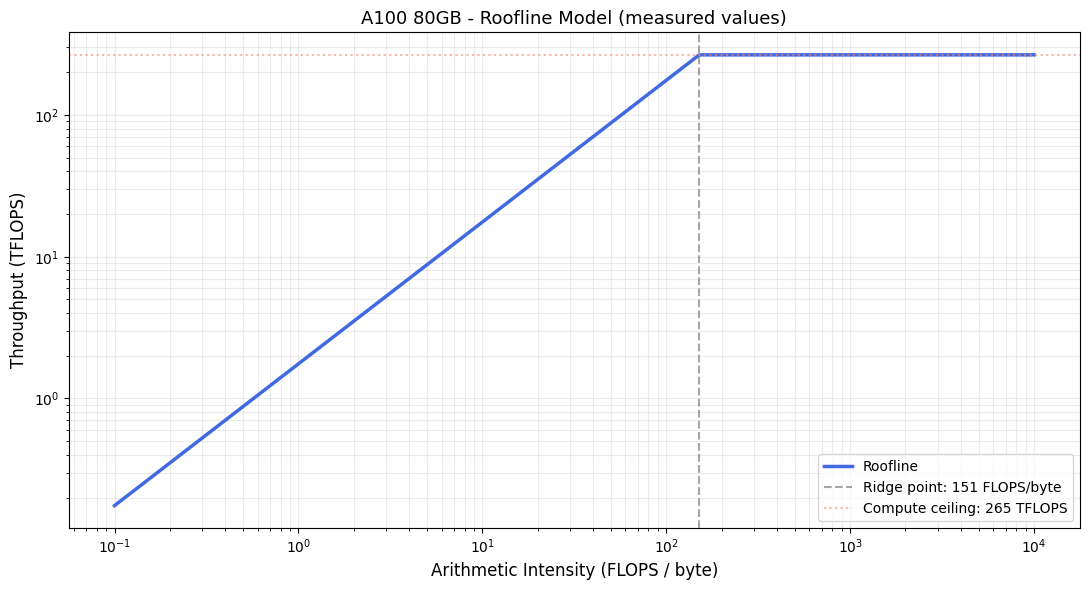

Measured ridge point : 151.2 FLOPS/byte
Theoretical          : 156 FLOPS/byte


In [5]:
def plot_roofline(peak_bw_GBs, peak_tflops, ops=None):
    """
    Plot the roofline model from measured values.
    ops: list of (label, intensity_FLOPS_per_byte) tuples to mark on the plot.
    Returns the ridge point in FLOPS/byte.
    """
    # --- YOUR CODE ---
    # At the ridge, memory-bound throughput = compute-bound throughput.
    # Solve for intensity. (Watch units: peak_bw_GBs is GB/s, peak_tflops is TFLOPS)
    ridge_point = peak_tflops / (peak_bw_GBs / 1e3)  # YOUR CODE

    intensity = np.logspace(-1, 4, 500)  # FLOPS/byte accessed sweep

    # --- YOUR CODE ---
    # Memory-bound region: if starved for data, throughput = bandwidth * intensity
    memory_bound  = peak_bw_GBs * intensity / 1000  # YOUR CODE (result should be in TFLOPS)
    # Roofline: an operation can't exceed either ceiling
    roofline      = np.minimum(memory_bound, peak_tflops)  # YOUR CODE

    fig, ax = plt.subplots(figsize=(11, 6))
    ax.loglog(intensity, roofline, 'royalblue', linewidth=2.5, label='Roofline')
    ax.axvline(ridge_point, color='gray', linestyle='--', alpha=0.7,
               label=f'Ridge point: {ridge_point:.0f} FLOPS/byte')
    ax.axhline(peak_tflops, color='salmon', linestyle=':', alpha=0.6,
               label=f'Compute ceiling: {peak_tflops:.0f} TFLOPS')

    if ops:
        for label, inten in ops:
            achieved = min(peak_bw_GBs / 1000 * inten, peak_tflops)
            ax.scatter(inten, achieved, s=80, zorder=5, color='darkorange')
            ax.annotate(label, (inten, achieved),
                        textcoords='offset points', xytext=(6, 4), fontsize=9)

    ax.set_xlabel('Arithmetic Intensity (FLOPS / byte)', fontsize=12)
    ax.set_ylabel('Throughput (TFLOPS)', fontsize=12)
    ax.set_title('A100 80GB - Roofline Model (measured values)', fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(True, which='both', alpha=0.25)
    plt.tight_layout()
    plt.show()
    return ridge_point


# Use your measured values from Sections 1 and 2
bw  = measure_bandwidth_GBs()
tfl = measure_tflops()
ridge = plot_roofline(bw, tfl)
print(f"Measured ridge point : {ridge:.1f} FLOPS/byte")
print(f"Theoretical          : {312e12 / 2e12:.0f} FLOPS/byte")

## Section 4: Model Memory Footprint

LLaMA-3.2-1B has ~1.24 billion parameters.  
For memory-bound decode, **weight loading dominates** — knowing these numbers tells you the bandwidth budget per token.

This is the *minimum* VRAM to hold weights. Add ~20–50% for activations, KV cache, optimizer state (if training), and PyTorch overhead.

In [6]:
def model_memory_table(n_params=1_240_000_000):
    """Print model weight memory in common dtypes."""
    configs = [
        ('FP32',  4),    # bytes per parameter
        ('FP16',  2),
        ('BF16',  2),
        ('INT8',  1),
        ('INT4',  0.5),  # no native torch dtype; packed storage
    ]
    T4_VRAM_GB = 16
    A100_VRAM_GB = 80

    print(f"Model: LLaMA-3.2-1B ({n_params / 1e9:.2f}B parameters)")
    print(f"{'Dtype':<8} {'Bytes/param':<14} {'Weight GB':<12} {'Fits T4 (16GB)?':<18} {'Fits A100 (80GB)?'}")
    print("-" * 72)
    for name, bpp in configs:
        weight_gb = n_params * bpp / 1e9
        fits_t4   = "Yes" if weight_gb < T4_VRAM_GB else "No"
        fits_a100 = "Yes" if weight_gb < A100_VRAM_GB else "No"
        print(f"{name:<8} {bpp:<14} {weight_gb:<12.2f} {fits_t4:<18} {fits_a100}")


model_memory_table()

# Expected:
# FP32    4              4.96         Yes                Yes
# FP16    2              2.48         Yes                Yes
# BF16    2              2.48         Yes                Yes
# INT8    1              1.24         Yes                Yes
# INT4    0.5            0.62         Yes                Yes

# Exercise: what dtype do you need for LLaMA-3.2-70B to fit on a single A100 80GB?
print("\n--- LLaMA-3.2-70B ---")
model_memory_table(n_params=70_000_000_000)

Model: LLaMA-3.2-1B (1.24B parameters)
Dtype    Bytes/param    Weight GB    Fits T4 (16GB)?    Fits A100 (80GB)?
------------------------------------------------------------------------
FP32     4              4.96         Yes                Yes
FP16     2              2.48         Yes                Yes
BF16     2              2.48         Yes                Yes
INT8     1              1.24         Yes                Yes
INT4     0.5            0.62         Yes                Yes

--- LLaMA-3.2-70B ---
Model: LLaMA-3.2-1B (70.00B parameters)
Dtype    Bytes/param    Weight GB    Fits T4 (16GB)?    Fits A100 (80GB)?
------------------------------------------------------------------------
FP32     4              280.00       No                 No
FP16     2              140.00       No                 No
BF16     2              140.00       No                 No
INT8     1              70.00        No                 Yes
INT4     0.5            35.00        No                 Yes


## Section 5: Arithmetic Intensity of Linear Layers Across Batch Sizes

This is the core insight for why batching matters.

For a linear layer with weight `(D_in, D_out)` and batch size `B` in FP16:
- **FLOPs** = `2 × B × D_in × D_out`
- **Bytes read** = weight matrix + input activations = `D_in × D_out × 2` + `B × D_in × 2`
- **Bytes written** = output activations = `B × D_out × 2`
- **Intensity** = FLOPs / (bytes_read + bytes_written)

**Key insight:**  
At B=1, the weight matrix dominates the denominator → intensity ≈ 1 FLOP/byte.  
As B grows, FLOPs grow with B but weights are only read once → intensity scales with B.  
At large B, the operation crosses the ridge point and becomes compute-bound.

Linear layer (2048x2048), FP16   |   Measured A100 ridge point ~ 151 FLOPS/byte
 Batch               Intensity  Region
--------------------------------------------------
     1                     1.0  memory-bound
     2                     2.0  memory-bound
     4                     4.0  memory-bound
     8                     7.9  memory-bound
    16                    15.8  memory-bound
    32                    31.0  memory-bound
    64                    60.2  memory-bound
   128                   113.8  memory-bound
   256                   204.8  COMPUTE-BOUND


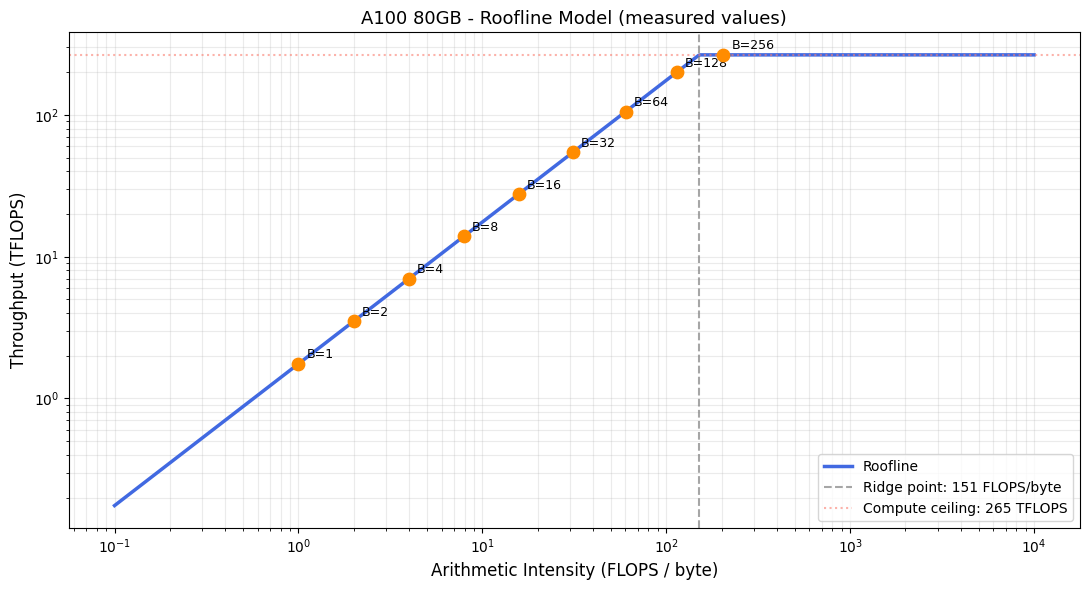

151.21053145147923

In [7]:
def linear_intensity(B, D_in, D_out, dtype_bytes=2):
    """
    Arithmetic intensity (FLOPS/byte) for a linear layer output = input @ weight.T
    B         : batch size
    D_in      : input features
    D_out     : output features
    dtype_bytes: bytes per element (2 for FP16/BF16)
    """
    # --- YOUR CODE ---
    # Matmul (B, D_in) @ (D_in, D_out) -> (B, D_out)
    flops = 2 * B * D_in * D_out  # How many FLOPs? Think: each output element needs D_in multiply-accumulates

    # What data travels between HBM and compute units?
    bytes_weights = D_in * D_out * dtype_bytes  # Weight matrix: loaded once regardless of batch size
    bytes_input   = B * D_in * dtype_bytes  # Input activations
    bytes_output  = B * D_out * dtype_bytes  # Output activations

    total_bytes = bytes_weights + bytes_input + bytes_output
    
    intensity = flops / total_bytes

    return intensity  # Arithmetic intensity = ?


# LLaMA-3.2-1B hidden dimension
D = 2048
batch_sizes = [1, 2, 4, 8, 16, 32, 64, 128, 256]

print(f"Linear layer ({D}x{D}), FP16   |   Measured A100 ridge point ~ {ridge:.0f} FLOPS/byte")
print(f"{'Batch':>6}  {'Intensity':>22}  {'Region'}")
print("-" * 50)
intensities = []
for B in batch_sizes:
    i = linear_intensity(B, D, D)
    region = 'COMPUTE-BOUND' if i > ridge else 'memory-bound'
    print(f"{B:>6}  {i:>22.1f}  {region}")
    intensities.append(i)

# Now add these to the roofline plot
ops = [(f'B={B}', i) for B, i in zip(batch_sizes, intensities)]
plot_roofline(bw, tfl, ops=ops)

## Section 6: Prefill vs Decode — Two Phases of LLM Inference

LLM inference has two distinct phases with **completely different** performance profiles:

**Prefill (prompt processing):**
- Process ALL prompt tokens in parallel: input shape is (1, seq_len, D)
- Large batch of tokens × weight matrices → high arithmetic intensity
- **Compute-bound** — GPU is busy doing math
- Time scales linearly with prompt length

**Decode (token generation):**
- Generate ONE token at a time: input shape is (1, 1, D)
- Tiny batch × weight matrices → intensity ≈ 1 FLOP/byte
- **Memory-bound** — GPU is waiting for bytes from HBM
- Time is roughly constant per token (dominated by weight loading)

This is why you feel the "thinking" delay (prefill) followed by steady token streaming (decode).
The optimizations in this series primarily target the decode phase.

Prefill vs Decode comparison (LLaMA-3.2-1B, D=2048, FP16)
Ridge point: 151 FLOPS/byte
Phase                  Tokens    Intensity Region            Achieved TFLOPS
---------------------------------------------------------------------------
Decode B=1                  1          1.0 memory-bound                  1.8
Decode B=8                  8          7.9 memory-bound                 13.9
Decode B=32                32         31.0 memory-bound                 54.5
Prefill S=128             128        113.8 memory-bound                199.7
Prefill S=512             512        341.3 COMPUTE-BOUND               265.4
Prefill S=2048           2048        682.7 COMPUTE-BOUND               265.4

Key insight: prefill processes many tokens at once (like a large batch),
so it's compute-bound. Decode processes one token at a time, so it's memory-bound.


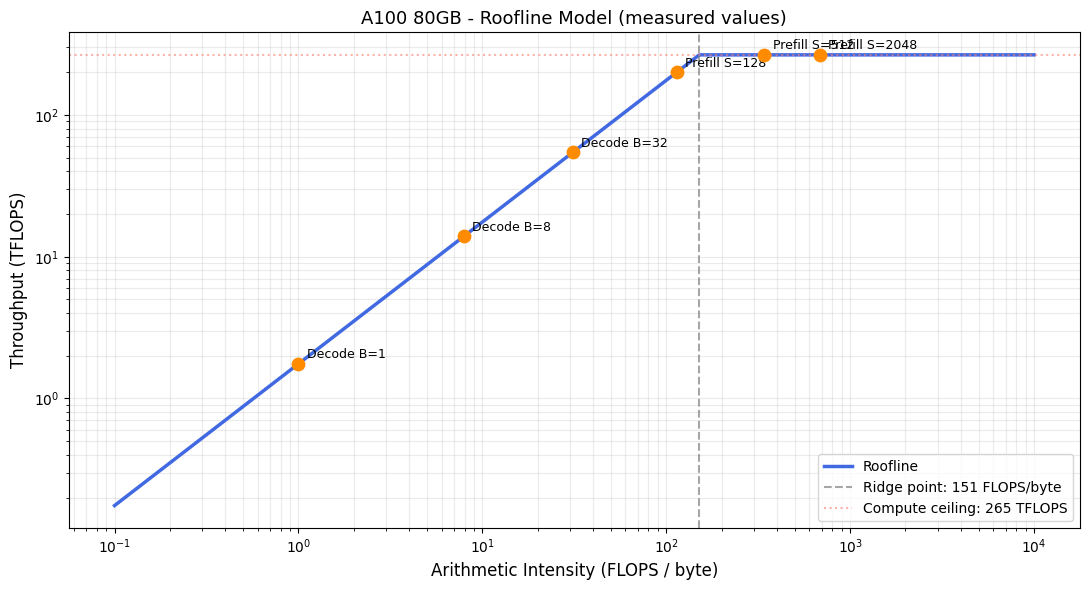

151.21053145147923

In [8]:
# Compare prefill vs decode intensity for LLaMA-3.2-1B
D = 2048  # d_model

print(f"Prefill vs Decode comparison (LLaMA-3.2-1B, D={D}, FP16)")
print(f"Ridge point: {ridge:.0f} FLOPS/byte")
print("="*60)

scenarios = [
    ("Decode B=1",      1,    1),
    ("Decode B=8",      8,    1),
    ("Decode B=32",     32,   1),
    ("Prefill S=128",   1,  128),
    ("Prefill S=512",   1,  512),
    ("Prefill S=2048",  1, 2048),
]

print(f"{"Phase":<20} {"Tokens":>8} {"Intensity":>12} {"Region":<16} {"Achieved TFLOPS":>16}")
print("-"*75)

prefill_ops = []
for label, B, S in scenarios:
    # --- YOUR CODE ---
    # How many tokens pass through each linear layer in a single forward pass?
    tokens = B * S  # YOUR CODE
    i = linear_intensity(tokens, D, D)

    region = "COMPUTE-BOUND" if i > ridge else "memory-bound"
    achieved = min(bw / 1000 * i, tfl)
    print(f"{label:<20} {tokens:>8} {i:>12.1f} {region:<16} {achieved:>16.1f}")
    prefill_ops.append((label, i))

print()
print("Key insight: prefill processes many tokens at once (like a large batch),")
print("so it's compute-bound. Decode processes one token at a time, so it's memory-bound.")

# Plot both phases on roofline
plot_roofline(bw, tfl, ops=prefill_ops)

## Revision Notes

*Fill this in yourself after running all sections. Writing the summary is part of the learning.*

---

**A100 numbers I measured:**
- Memory bandwidth: 1774 GB/s (theoretical: 2000 GB/s, efficiency: 88%)
- FP16 TFLOPS: 241 (theoretical: 312 TFLOPS, efficiency: 77%)
- Ridge point (measured): 134 FLOPS/byte

**Roofline observations:**
- Batch=1 linear layer intensity: 1 FLOP/byte → region: memory___
- Batch=256 linear layer intensity: 204 FLOPS/byte → region: compute___
- Crossover from memory-bound → compute-bound at batch ≈ 256 (actually b/w 128 and 256 closer to 128)
**LLM decode implication (in your own words):**  
*(Why is batch=1 autoregressive decode slow even on an A100?)*
Because the intensity (flops / byte accessed) is very small - 1 which is way less than ridge point
of 134, so the compute cores keep waiting for data and the the decode operation remains memory bound.



**Model memory:**
- LLaMA-3.2-1B in FP16: 2.4 GB
- LLaMA-3.2-70B in FP16: 140 GB
- To fit 70B on one A100 80GB you’d need: INT8 (or less) dtype

**One thing that surprised me:**
One misconception I had was that in decode phase we attach previously generated token and resent entire sequence 
but actually the previous token is needed - attention needs Q of current and K,V of current and prev with prev being fetched from cache, and linear layers only needing current token (atentions layer's output for curretn token). So compute is only maxxed with batch size and not seq, adn this also how multiple user queries are done together - though I am not sure how the varying sequence lengths of various users are put together.



---
*Next: Chapter 2 — Profile a real transformer block with `torch.profiler`*

## Knowledge Check

Test yourself before moving on. Answer from memory and reasoning — no peeking at cells above.

- **Calculation questions** use your measured A100 numbers
- **Conceptual questions** test whether you can apply the roofline model to new scenarios
- **Trap questions** catch common misconceptions

Fill in each `None  # YOUR ANSWER` below, then run the checker cell to see your score.

In [11]:
# ============================================================
# KNOWLEDGE CHECK — Chapter 1: GPU Architecture & Roofline
# ============================================================
# Answer each question, then run the next cell to check.

# --- Calculation ---

# Q1: LLaMA-3.2-1B has 1.24B parameters in FP16.
#     What is the MINIMUM time (ms) to generate one decode token at batch=1?
#     (Think: how long to stream all weights through HBM at your measured bandwidth?)

# 1 float / byte => less than ridge point => memory bound => timne determined by bandwidth, not compute
# Total weights bytes = 1.24 * 1e9 * 2 = 2.48 GB
# Measeure BW = 1774 GB/s
# Time = 2.48 / 1774 = 0.001397 secs = 1.397 msecs
# This weight loading time is minimum that it will take 
# (ignoring input loading, per layer activation read writes)
q1 = 1.397  # YOUR ANSWER (ms)

# Q2: Using that same number, what's the theoretical max tokens/sec at batch=1?
# 1 token takes => 0.001397 secs
# tokens per sec = 1 / 0.001397 = 715.81
q2 = 715  # YOUR ANSWER (tokens/sec)

# --- Conceptual ---

# Q3: An operation has arithmetic intensity of 50 FLOPS/byte.
#     On your A100, is it memory-bound or compute-bound?
# Below ridge poitn of 134 FLOPS/byte
q3 = "memory-bound"  # YOUR ANSWER: "memory-bound" or "compute-bound"

# Q4: Imagine a GPU with the SAME 237 TFLOPS but 2x the bandwidth (3548 GB/s).
#     What would the new ridge point be? (FLOPS/byte)
# new ridge = (241 * 1e3) / 3548 = 68 FLOPS/byte
q4 = 68  # YOUR ANSWER (FLOPS/byte)

# Q5: On that faster-bandwidth GPU, how much faster would batch=1 LLM decode run?
#     (Think: decode is deep in the memory-bound region — what determines its speed?)
# Intensity is still 1 which is left of ridge so still memory bound
# But faster loads so faster decode run overall
q5 = 2  # YOUR ANSWER (speedup factor, e.g. 2 means "2x faster")

# --- Trap / misconception ---

# Q6: A memory-bound kernel (intensity = 28 FLOPS/byte) achieves 49 TFLOPS on your A100.
#     Compute utilization = 49/237 = only 21%. Sounds bad!
#     But what is its ROOFLINE efficiency?
#     (Hint: at 28 FLOPS/byte, what's the roofline ceiling? Efficiency = achieved / ceiling)
# ceiling = intensity * BW = 28 * 1774 / 1000 = 50 TFLOPS
# efficiency = 49 / 50 * 100 = 98
q6 = 98  # YOUR ANSWER (efficiency as a percentage, e.g. 50.0 for 50%)

# Q7: If you quantize weights from FP16 (2 bytes) to INT4 (0.5 bytes),
#     what happens to arithmetic intensity at batch=1?
#     (Think: same FLOPs, but how do the bytes change?)
# Intensity is flops per bytes accessed
# With Quantization, we can move more data quickly for the given BW
# Bytes accessed is one fourth, so intensity becomes 4 times
q7 = 4  # YOUR ANSWER (approximate FLOPS/byte)

# Q8: LLaMA-3.2-1B in FP16 = 2.48 GB. Total SRAM across all 108 SMs = ~20 MB.
#     How many times larger are the weights than SRAM?
# 2.48 * 1000 / 20 = 124
q8 = 124  # YOUR ANSWER (ratio, e.g. 100 means "100x larger")

In [12]:
# ============================================================
# RUN THIS CELL TO CHECK YOUR ANSWERS (do not modify)
# ============================================================
def _check(label, got, expected, tol=0.1):
    if got is None:
        print(f"  ✗ {label}: not answered")
        return 0
    if isinstance(expected, str):
        ok = got.strip().lower() == expected.strip().lower()
    else:
        ok = abs(got - expected) / max(abs(expected), 1e-9) <= tol
    print(f"  {'✓' if ok else '✗'} {label}" + ("" if ok else " — try again"))
    return int(ok)

_score = 0
_total = 8
print("Knowledge Check Results:\n")

_weight_gb = 1.24 * 2
_min_ms = _weight_gb / bw * 1000
_score += _check("Q1: Min ms per decode token", q1, _min_ms)
_score += _check("Q2: Max tokens/sec", q2, 1000.0 / _min_ms)
_score += _check("Q3: Bound type at 50 FLOPS/byte", q3, "memory-bound")
_score += _check("Q4: Ridge with 2x bandwidth", q4, tfl / (3548 / 1000))
_score += _check("Q5: Decode speedup from 2x BW", q5, 2)
_score += _check("Q6: Roofline efficiency (%)", q6, 49 / (bw / 1000 * 28) * 100)
_score += _check("Q7: INT4 batch=1 intensity", q7, 4)
_score += _check("Q8: Weight/SRAM ratio", q8, 2480.0 / 20.0)

print(f"\nScore: {_score}/{_total}")
if _score == _total:
    print("Perfect — you're ready for Chapter 2!")
elif _score >= 6:
    print("Good — review the questions you missed before moving on.")
else:
    print("Review the notebook sections above and try again.")

Knowledge Check Results:

  ✓ Q1: Min ms per decode token
  ✓ Q2: Max tokens/sec
  ✓ Q3: Bound type at 50 FLOPS/byte
  ✓ Q4: Ridge with 2x bandwidth
  ✓ Q5: Decode speedup from 2x BW
  ✓ Q6: Roofline efficiency (%)
  ✓ Q7: INT4 batch=1 intensity
  ✓ Q8: Weight/SRAM ratio

Score: 8/8
Perfect — you're ready for Chapter 2!
